# Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** [Muhammad Anees]

**Student ID:** [023-24-0251]

**GitHub Profile:** [https://github.com/Anees-Memon-Hub]

**Kaggle Profile:** [https://www.kaggle.com/aneesmemon]

**Dataset:** Telco Customer Churn (cleaned in Lab 2 — `clean_churn.csv`)

**Dataset Source:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


## Part 1 — Problem Definition & Dataset Verification

**Tasks**

1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [1]:
# Task 1 — Loading and verifying the cleaned dataset from Lab 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values remaining:", df.isnull().sum().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

df.head()

Shape: (7043, 20)

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values remaining: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,Yes,43,Yes,Yes,Fiber Optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,Male,0,Yes,Yes,67,Yes,Yes,Fiber Optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,Female,1,No,No,1,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,Female,1,Yes,No,72,Yes,Yes,Dsl,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,Female,0,No,No,69,Yes,No,Dsl,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


**Answer 2 (restating the problem):**

The variable that I am predicting is the Churn, which is based on whether the customer will terminate their subscription with the telecommunications company (Yes/No). This has some significance for the business as it helps the firm in identifying those customers that are likely to leave and take measures to retain them.

---

## Part 2 — Feature & Target Preparation

**Tasks**

3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [2]:
# Task 3 — Define target (y) and features (X)

# Encode the target variable: No = 0, Yes = 1
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Remove the target column from the features
X = df.drop(columns=['Churn'])

# Check for identifier-like columns
id_like = [c for c in X.columns if 'id' in c.lower()]

print("Identifier-like columns found:", id_like)

# Remove identifier-like columns if any exist
X = X.drop(columns=id_like)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Identifier-like columns found: []

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target distribution (%):
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


**Justification for Task 3:**

`Churn` has been transformed into 0/1 (`No` = 0; `Yes` = 1), thus making the target variable numeric, which is needed for scikit-learn. There is no identifier column left in `X` (`customerID`), since it has been removed during the Lab 2 data preparation.

In [3]:
# Task 4 — Convert categorical features into numeric form

# Find all categorical (text) columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:")
print(cat_cols)

# Apply one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nShape of X after encoding:", X.shape)
X.head()

Categorical columns to encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape of X after encoding: (7043, 30)


C:\Users\memon\AppData\Local\Temp\ipykernel_17028\955022561.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,43,99.30,4209.95,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
1,0,67,89.55,6038.55,True,True,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
2,1,1,71.15,71.15,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,72,89.85,6697.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
4,0,69,82.45,5555.30,False,False,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False


**Answer 4 (encoding choice justification):**

I used one hot encoding using `pd.get_dummies()` since there is no natural numeric ordering for any of the categorical features (`gender`, `Contract`, `Internet Service`, `Payment Method`, etc.). For example, assuming a manual numeric encoding such as `Month-to-month`=0, `One Year`=1, `Two Year`=2 would be misleading since there is no ordering relationship between the categories. Using one hot encoding ensures that there is a column for each of the categorical values. `drop_first=True` removes the redundancy of having perfectly collinear dummy columns.

In [4]:
# Task 5 — Confirm X contains only numeric columns and no missing values

non_numeric = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()
print("Non-numeric columns remaining:")
print(non_numeric if non_numeric else "None")

missing_values = X.isnull().sum().sum()
print("\nMissing values in X:", missing_values)

print("\nFinal X shape:", X.shape)
print("\nData type counts:")
print(X.dtypes.value_counts())

Non-numeric columns remaining:
None

Missing values in X: 0

Final X shape: (7043, 30)

Data type counts:
bool       26
int64       2
float64     2
Name: count, dtype: int64


**Observation:** Once the process of one-hot encoding is completed, all the columns of `X` will be numerical (integer/float) or boolean, and there will be no missing value. It is to be noted that `X` now has 30 columns compared to the earlier 19 as each multi-categorical variable has been decomposed into multiple binary dummy variables.

---

## Part 3 — Train/Test Split

**Tasks**

6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [7]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Churn rate in y_train:", round(y_train.mean(), 4))
print("Churn rate in y_test:", round(y_test.mean(), 4))
print("Churn rate in full y:", round(y.mean(), 4))


Churn rate in y_train: 0.2654
Churn rate in y_test: 0.2654
Churn rate in full y: 0.2654


**Answer 6 (why `stratify=y` is sensible):**

As observed in Lab 2, the class variable, `Churn`, was not balanced with `73.5%` "No" and `26.5%` "Yes". Setting `stratify=y` ensures that the split retains the same proportion for the training and test datasets. This way, the chances of over- or under-sampling churn customers in the test dataset are reduced. It is observed in the output above that the proportion of customers who have churned is the same in all three datasets.

In [8]:
# Task 7 — report shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


**Observation:** Data was partitioned into 5,634 train rows and 1,409 test rows with 30 features in each. The same churn rate (0.2654) for training set, test set, and entire dataset validates stratification.

---

## Part 4 — Baseline Decision Tree

**Tasks**

8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [9]:
# Task 8 — baseline Decision Tree
from sklearn.tree import DecisionTreeClassifier

baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

train_pred_base = baseline_model.predict(X_train)
test_pred_base = baseline_model.predict(X_test)

print("Baseline tree trained.")

Baseline tree trained.


In [10]:
# Task 9 — how deep did the tree grow on its own?
print("Depth scikit-learn grew the baseline tree to:", baseline_model.get_depth())
print("Number of leaves:", baseline_model.get_n_leaves())

Depth scikit-learn grew the baseline tree to: 24
Number of leaves: 1088


**Answer 9 (does the depth surprise me?):**

If left unchecked, scikit-learn created a tree that went all the way up to a depth of 24 with 1,088 leaves. This is a huge number of splits with just 30 features and roughly 5,600 training samples – it seems like the tree continued splitting until each of the training examples ended up in its own small leaf..

---

## Part 5 — Model Evaluation

**Tasks**

10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [11]:
# Task 10 — accuracy, precision, recall, F1 on the test set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

acc = accuracy_score(y_test, test_pred_base)
prec = precision_score(y_test, test_pred_base)
rec = recall_score(y_test, test_pred_base)
f1 = f1_score(y_test, test_pred_base)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline (test set)": [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
})
metrics_table

,Metric,Baseline (test set)
0,Accuracy,0.7268
1,Precision,0.4848
2,Recall,0.4706
3,F1-score,0.4776


[[848 187]
 [198 176]]


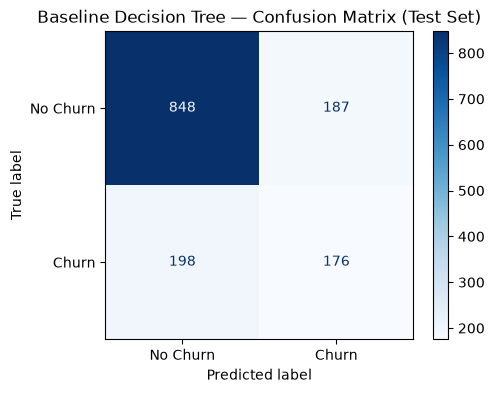

In [12]:
# Task 11 — confusion matrix for the test set
cm = confusion_matrix(y_test, test_pred_base)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Baseline Decision Tree — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 11):** Of the 374 test customers who truly churned, the baseline classifier managed to detect 176 (true positives), but failed to detect 198 (false negatives – those classified as "No" when they truly churned). Additionally, it generated 187 false positives (those falsely predicted as "Churn" while retaining their connections). In other words, the baseline classifier fails to detect more than half of the true churning customers, which makes the model highly unreliable for pro-active retention.

**Answer 12 (which metric(s) to trust):** Considering the fact that there was about a 73.5%/26.5% class imbalance as seen in Lab 2, then accuracy is not a good metric. This is because predicting the 'No Churn' class will be enough to give an accuracy of about 73.5% even without catching any of the churners. In my view, for the above-mentioned problem, I consider **recall** and **F1-score** on the churn class as the metrics. Recall will provide how many of the churners have been identified (important for the business), while F1 ensures that precision is also considered.

---

## Part 6 — Overfitting Investigation

**Tasks**

13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [11]:
# Task 13 — baseline train vs. test accuracy
train_acc_base = accuracy_score(y_train, train_pred_base)
test_acc_base = accuracy_score(y_test, test_pred_base)

print("Baseline training accuracy:", round(train_acc_base, 4))
print("Baseline test accuracy:", round(test_acc_base, 4))
print("Gap (train - test):", round(train_acc_base - test_acc_base, 4))

Baseline training accuracy: 0.9977
Baseline test accuracy: 0.7268
Gap (train - test): 0.2709


**Answer 13 (is there a large gap?):**

Yes, and quite an impressive one! Unrestricted tree score is 99.8% correct on the training data, while being only 72.7% accurate on the test data, which makes the difference of around 27 percentage points. When we consider the depth of 24 levels for this tree, we may clearly identify the signs of overfitting — a tree has simply learned the training data by heart, including its flaws.

In [16]:
# Task 14 — train/test accuracy across several max_depth values
depths_to_try = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths_to_try:
    model_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    model_d.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, model_d.predict(X_train))
    te_acc = accuracy_score(y_test, model_d.predict(X_test))

    results.append({
        "max_depth": "None (unrestricted)" if d is None else d,
        "Train Accuracy": round(tr_acc, 4),
        "Test Accuracy": round(te_acc, 4)
    })

depth_results = pd.DataFrame(results)
depth_results

,max_depth,Train Accuracy,Test Accuracy
0,2,0.7881,0.7700
1,3,0.7881,0.7700
2,4,0.7929,0.7835
3,5,0.8078,0.7743
4,6,0.8152,0.7693
5,8,0.8449,0.7715
6,10,0.8821,0.7445
7,None (unrestricted),0.9977,0.7268


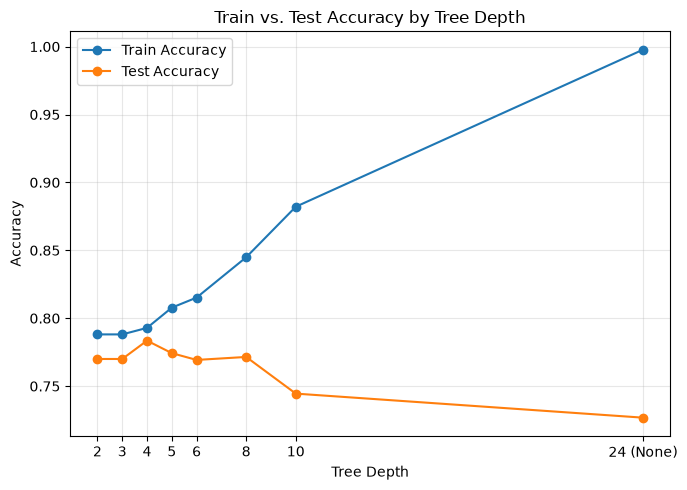

In [14]:
# Task 15 — plot train vs. test accuracy against max_depth
plot_depths = [2, 3, 4, 5, 6, 8, 10, 24]  # 24 = the depth the unrestricted tree actually reached

train_accs = depth_results["Train Accuracy"].tolist()
test_accs = depth_results["Test Accuracy"].tolist()

plt.figure(figsize=(7, 5))
plt.plot(plot_depths, train_accs, marker='o', label='Train Accuracy')
plt.plot(plot_depths, test_accs, marker='o', label='Test Accuracy')

plt.xticks(plot_depths, ['2', '3', '4', '5', '6', '8', '10', '24 (None)'])
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy by Tree Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Answer 15 (where does overfitting start, and how does the chart show it?):**

Until `max_depth=4`, train and test accuracies follow each other quite closely, and the maximum value of test accuracy (78.35%) is achieved at depth 4. After `max_depth=5`, train accuracy continues to increase (to 99.77% without any limitations), whereas test accuracy *decreases* and continues decreasing (77.4% → 76.9% → 77.2% → 74.5% → 72.7%). The increasing difference between train and test accuracies with the growth of `max_depth` is a clear sign of overfitting, which becomes evident starting from depth 5.

---

## Part 7 — Model Selection, Feature Importance & Interpretation

**Tasks**

16. Based on your Part 6 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline.
18. Retrain a Decision Tree with "entropy" as the splitting criterion rather than the default ("gini") and report its full evaluation metrics (as in Part 5) for comparison against the baseline.
19. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?
20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 16 (chosen depth and justification):**

I will go with **`max_depth=4`**. Based on the values in the table from Part 6, the tree at depth 4 achieves the **best testing accuracy**, out of all tested depths (78.35%), and with a narrow gap between the train and test sets of just 1.5 percentage points (train: 79.29%, test: 78.35%) — much better than at depth 10 (train: 88.21%, test: 74.45%) or the unbounded tree (train: 99.77%, test: 72.68%). Not that I would choose a deeper tree solely based on its training accuracy being higher, as we know from Part 6 that it actually makes the model remember the training set rather than predict customer churn.

In [ ]:
# Task 17 — Retrain at the chosen depth (max_depth=4) and evaluate fully

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Baseline model predictions

baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)

# Baseline metrics
baseline_train_acc = accuracy_score(y_train, baseline_train_pred)
baseline_test_acc = accuracy_score(y_test, baseline_test_pred)
baseline_prec = precision_score(y_test, baseline_test_pred)
baseline_rec = recall_score(y_test, baseline_test_pred)
baseline_f1 = f1_score(y_test, baseline_test_pred)



# Chosen model: max_depth = 4

chosen_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

chosen_model.fit(X_train, y_train)

chosen_train_pred = chosen_model.predict(X_train)
chosen_test_pred = chosen_model.predict(X_test)

# Chosen model metrics
chosen_train_acc = accuracy_score(y_train, chosen_train_pred)
chosen_test_acc = accuracy_score(y_test, chosen_test_pred)
chosen_prec = precision_score(y_test, chosen_test_pred)
chosen_rec = recall_score(y_test, chosen_test_pred)
chosen_f1 = f1_score(y_test, chosen_test_pred)

# Comparison table

chosen_metrics = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Baseline (unrestricted)": [
        baseline_train_acc,
        baseline_test_acc,
        baseline_prec,
        baseline_rec,
        baseline_f1
    ],

    "Chosen (max_depth=4)": [
        chosen_train_acc,
        chosen_test_acc,
        chosen_prec,
        chosen_rec,
        chosen_f1
    ]
})

chosen_metrics.round(4)

,Metric,Baseline (unrestricted),Chosen (max_depth=4)
0,Train Accuracy,0.9977,0.7929
1,Test Accuracy,0.7268,0.7835
2,Precision,0.4848,0.5856
3,Recall,0.4706,0.6310
4,F1-score,0.4776,0.6075


[[868 167]
 [138 236]]


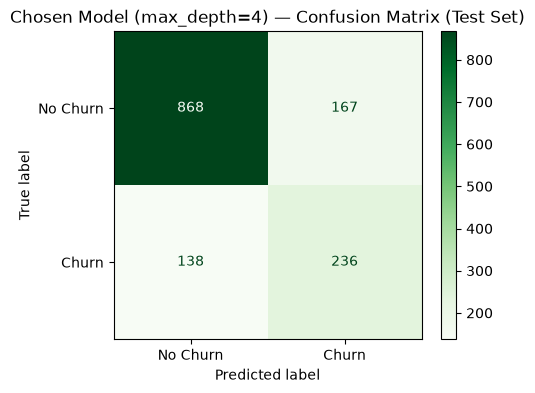

In [20]:
cm_chosen = confusion_matrix(y_test, chosen_test_pred)
print(cm_chosen)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_chosen, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, cmap="Greens", values_format='d')
plt.title("Chosen Model (max_depth=4) — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 17):**

Compared with the unrestricted baseline, the depth-4 model has lower training accuracy (79.29% compared with 99.77%) but achieves better test accuracy (78.35% compared with 72.68%). It also performs better at identifying customers who are likely to churn, with recall improving from 47.06% to 63.10%, precision from 48.48% to 58.56%, and F1-score from 47.76% to 60.75%. The confusion matrix shows that the model correctly identifies 236 out of 374 actual churners, while missing 138. Overall, the depth-4 tree appears to generalize better than the unrestricted tree and is more useful for identifying customers who may be at risk of churning

In [22]:
# Task 18 — Compare Gini and Entropy criteria
entropy_model = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)

entropy_train_pred = entropy_model.predict(X_train)
entropy_test_pred = entropy_model.predict(X_test)

criterion_compare = pd.DataFrame({
    "Metric": ["Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1-score"],
    "Gini (chosen)": [
        round(accuracy_score(y_train, chosen_train_pred), 4),
        round(accuracy_score(y_test, chosen_test_pred), 4),
        round(precision_score(y_test, chosen_test_pred), 4),
        round(recall_score(y_test, chosen_test_pred), 4),
        round(f1_score(y_test, chosen_test_pred), 4),
    ],
    "Entropy": [
        round(accuracy_score(y_train, entropy_train_pred), 4),
        round(accuracy_score(y_test, entropy_test_pred), 4),
        round(precision_score(y_test, entropy_test_pred), 4),
        round(recall_score(y_test, entropy_test_pred), 4),
        round(f1_score(y_test, entropy_test_pred), 4),
    ]
})
criterion_compare

,Metric,Gini (chosen),Entropy
0,Train Accuracy,0.7929,0.7920
1,Test Accuracy,0.7835,0.7850
2,Precision,0.5856,0.6550
3,Recall,0.6310,0.4011
4,F1-score,0.6075,0.4975


**Observation (Task 18 — gini vs. entropy):**

At the same level of depth, the entropy tree performs better than the Gini tree in terms of test accuracy (78.50% vs 78.35%) and precision (65.50% vs 58.56%), but the recall of the entropy tree is much lower for the churn class (40.11% vs 63.10%) and so is the F1-score (49.75% vs 60.75%). Given that detecting actual churns is more important than being careful about false positive churn predictions, it makes sense to go with the **Gini tree** as the final model.

### Feature Importance

**Task 19** — Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

tenure                              0.491171
InternetService_Fiber Optic         0.354303
Contract_Two year                   0.037832
OnlineBackup_No internet service    0.030605
TotalCharges                        0.027346
dtype: float64


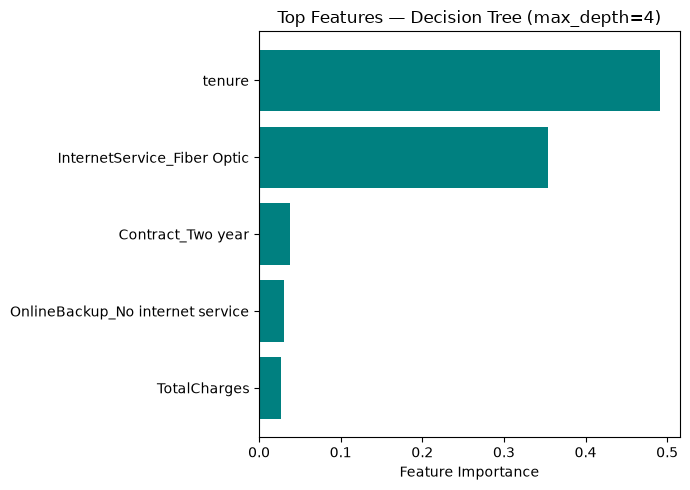

In [26]:
# Task 19 — feature importances for the chosen model
importances = pd.Series(chosen_model.feature_importances_, index=X.columns)
importances = importances[importances > 0].sort_values(ascending=False)

top_features = importances.head(5)
print(top_features)

plt.figure(figsize=(7, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='teal')
plt.xlabel('Feature Importance')
plt.title('Top Features — Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

**Observation (Task 19):** The two most significant variables by far are **`tenure`** (importance ≈ 0.49) and **`InternetService_Fiber Optic`** (≈ 0.35). Together, they constitute the vast majority of the tree's split rules at this stage. Next to them, we see a sharp drop in importance; the third and fourth places go to **`Contract_Two year`** (≈ 0.038) and **`OnlineBackup_No internet service`** (≈ 0.031); fifth place goes to **`TotalCharges`** (≈ 0.027). This means that the tree almost exclusively uses tenure and fiber-optic internet services in making its decisions.

### Interpretation

**Task 20** — In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 20 (connecting feature importance back to Lab 2 EDA):**

Yes, this is consistent with the Lab 2 EDA. There was a definite pattern between `tenure` and churn, whereby customers who churned were seen to have much lower tenure compared to those that remained, and it is currently the most important feature on this decision tree. `InternetService` as well as Fiber Optic customers were seen to have higher churn rates compared to others in the EDA, and that is why it is the second most important feature on this tree. Similarly, `Contract` with longer contract periods linked with lower churn rates appears in the tree as `Contract_Two year`.

---

## Part 8 — Conclusion & Next Steps

**Task 21** — Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?

**Answer 21 (conclusion):**

I chose **Decision Tree with `max_depth=4` and Gini criterion by default** as my final model. It definitely performs better than the baseline model on new data, scoring **78.35% test accuracy, 58.56% precision, 63.10% recall, and 60.75% F1-score**, whereas the baseline gets 72.68% test accuracy and only 47.06% recall, which means that it is able to detect more real churners, being also better at generalization (difference between train and test performance is about 1.5 points vs. 27 points). The disadvantages of this model are that it fails to detect about 37% of real churners (138 of 374 from the test dataset), uses only two features (`tenure` and `fiber-optic internet`) almost exclusively, and thus is quite rough and maybe too sensitive to customer changes, and is a simple shallow decision tree that cannot take into account more complicated feature interactions.

**Task 22** — What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 22 (next steps):**

With more time I would do the following: (1) test out ensemble techniques like Random Forest or Gradient Boosting, because they generally perform well on this type of tabular data better compared to a single decision tree and are not likely to exhibit such strong overfitting; (2) solve the class imbalance problem using techniques such as class weighting or sampling with class weights set to `'balanced'`; (3) generate some new features, for example, such as average spending trend per month, ratio of `TotalCharges` to `tenure`, or interaction between contract type and internet service; and (4) optimize parameters like `min_samples_leaf` and `min_samples_split` along with tuning `max_depth`.

**Task 23** — Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — write your own entropy and information gain functions. Print the gain values for each attribute at every split.

In [24]:
# Task 23 — ID3 from scratch on the Play Badminton dataset (no sklearn here)
import math
from collections import Counter

# Classic "Play Badminton" dataset from the AI course
play_badminton = pd.DataFrame({
    "Outlook":     ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                     "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                     "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity":    ["High","High","High","High","Normal","Normal","Normal",
                     "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
                     "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayBadminton": ["No","No","Yes","Yes","Yes","No","Yes",
                      "No","Yes","Yes","Yes","Yes","Yes","No"]
})
play_badminton

,Outlook,Temperature,Humidity,Wind,PlayBadminton
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [25]:
def entropy(labels):
    """Entropy of a list/Series of class labels."""
    counts = Counter(labels)
    total = len(labels)
    ent = 0.0
    for label, count in counts.items():
        p = count / total
        ent -= p * math.log2(p)
    return ent


def information_gain(data, attribute, target):
    """Information gain of splitting `data` on `attribute`, w.r.t. `target`."""
    total_entropy = entropy(data[target])
    total = len(data)

    weighted_entropy = 0.0
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / total) * entropy(subset[target])

    return total_entropy - weighted_entropy


def id3(data, attributes, target, depth=0):
    """Recursive ID3 that prints info gain at every split and returns a nested-dict tree."""
    indent = "  " * depth
    labels = data[target]

    # Pure node
    if len(set(labels)) == 1:
        print(f"{indent}Leaf -> {labels.iloc[0]} (pure, {len(data)} examples)")
        return labels.iloc[0]

    # No attributes left -> majority class
    if not attributes:
        majority = Counter(labels).most_common(1)[0][0]
        print(f"{indent}Leaf -> {majority} (no attributes left, majority class)")
        return majority

    # Compute information gain for every remaining attribute
    gains = {attr: information_gain(data, attr, target) for attr in attributes}
    print(f"{indent}Node with {len(data)} examples. Information gains:")
    for attr, g in sorted(gains.items(), key=lambda x: -x[1]):
        print(f"{indent}  {attr}: {g:.4f}")

    best_attr = max(gains, key=gains.get)
    print(f"{indent}--> Splitting on '{best_attr}' (gain = {gains[best_attr]:.4f})\n")

    tree = {best_attr: {}}
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        print(f"{indent}[{best_attr} = {value}]")
        if len(subset) == 0:
            majority = Counter(labels).most_common(1)[0][0]
            tree[best_attr][value] = majority
            print(f"{indent}  Leaf -> {majority} (empty subset, majority class)")
        else:
            tree[best_attr][value] = id3(subset, remaining_attrs, target, depth + 1)

    return tree


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]
tree = id3(play_badminton, attributes, "PlayBadminton")
print("\nFinal tree:")
print(tree)

Node with 14 examples. Information gains:
  Outlook: 0.2467
  Humidity: 0.1518
  Wind: 0.0481
  Temperature: 0.0292
--> Splitting on 'Outlook' (gain = 0.2467)

[Outlook = Sunny]
  Node with 5 examples. Information gains:
    Humidity: 0.9710
    Temperature: 0.5710
    Wind: 0.0200
  --> Splitting on 'Humidity' (gain = 0.9710)

  [Humidity = High]
    Leaf -> No (pure, 3 examples)
  [Humidity = Normal]
    Leaf -> Yes (pure, 2 examples)
[Outlook = Overcast]
  Leaf -> Yes (pure, 4 examples)
[Outlook = Rain]
  Node with 5 examples. Information gains:
    Wind: 0.9710
    Temperature: 0.0200
    Humidity: 0.0200
  --> Splitting on 'Wind' (gain = 0.9710)

  [Wind = Weak]
    Leaf -> Yes (pure, 3 examples)
  [Wind = Strong]
    Leaf -> No (pure, 2 examples)

Final tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


**Observation (Task 23):**

The selection of `Outlook` is made since this attribute yields the highest information gain (0.2467) out of the four attributes. The `Overcast` node is immediately classified as a pure leaf (`Yes`, all 4 examples), hence no further splits required. In the `Sunny` node, the next attribute with the highest information gain is `Humidity`, which results in two pure leaves (`High` → No, `Normal` → Yes). In the `Rain` node, the next attribute with the highest information gain is `Wind`, which results in two pure leaves (`Weak` → Yes, `Strong` → No).

---

## Submission Checklist

- [x] Student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Source)
- [x] 1. Problem Definition
- [x] 2. Dataset Verification
- [x] 3. Feature/Target Preparation
- [x] 4. Train/Test Split
- [x] 5. Baseline Decision Tree
- [x] 6. Model Evaluation (accuracy, precision, recall, F1, confusion matrix)
- [x] 7. Overfitting Experiment (train vs. test comparison + multi-depth table & plot)
- [x] 8. Model Comparison (chosen depth vs. baseline, gini vs. entropy)
- [x] 9. Feature Importance
- [x] 10. Interpretation (connected back to Lab 2 EDA)
- [x] 11. Conclusion & Next Steps
- [x] Task 23 — ID3 implemented from scratch on the Play Badminton dataset
- [x] Every table/plot/metric accompanied by a written interpretation